In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('../names.txt','r').read().splitlines()

In [4]:
## creating characters vocabulary
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?
def build_dataset(words):
    X, Y= [], []
    for w in words: 

        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print("'.join(itos[i] for i in context), '->', itos[ix])
            context = context[1:] + [ix] # crop and append

    X = torch. tensor(X)
    Y = torch. tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random. seed(42)
random. shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])            ## 80% for training
Xdev, Ydev = build_dataset(words[n1:n2])        ## 10% for development/validation
Xte, Yte = build_dataset(words[n2:])            ## 10% for testing

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [44]:

## Same code but more better structured 
n_embed = 10
n_hidden = 200
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embed), generator=g)
emb = C[Xtr]
w1 = torch.randn((n_embed*block_size, n_hidden), generator=g) * 0.1
b1 = torch.randn(n_hidden, generator=g) * 0.1
w2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0.1
parameters = [C,w1,b1,w2,b2]
length = sum(p.nelement() for p in parameters)
for p in parameters:
    p.requires_grad = True

In [45]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X,Y

    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1)  # concatenate the vectors
    hpreact = embcat @ w1  + b1  # hidden layer pre-activation
    ## batch normalisation
    h = torch.tanh(hpreact)  # hidden layer
    logits = h @ w2 + b2  # output layer (initial loss depens of w2 and b2 so lets update date)
    loss = F.cross_entropy(logits, Yb)  # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:  # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    break ## we are chcking the first loss value and as we can see it is really high 27.881, now if all the characters should have a same probability of coming next then 
## initial loss should be 3.29 somthing as 1/27 so now we will try to decrease the initail loss

      0/ 200000: 3.3094
  10000/ 200000: 2.1958
  20000/ 200000: 2.2788
  30000/ 200000: 2.4946
  40000/ 200000: 1.9770
  50000/ 200000: 2.4895
  60000/ 200000: 2.3614
  70000/ 200000: 1.9905
  80000/ 200000: 2.2957
  90000/ 200000: 2.0929
 100000/ 200000: 1.9165
 110000/ 200000: 2.2407
 120000/ 200000: 1.9127
 130000/ 200000: 2.3768
 140000/ 200000: 2.2491
 150000/ 200000: 2.1792
 160000/ 200000: 1.8824
 170000/ 200000: 1.7944
 180000/ 200000: 1.9951
 190000/ 200000: 1.8000


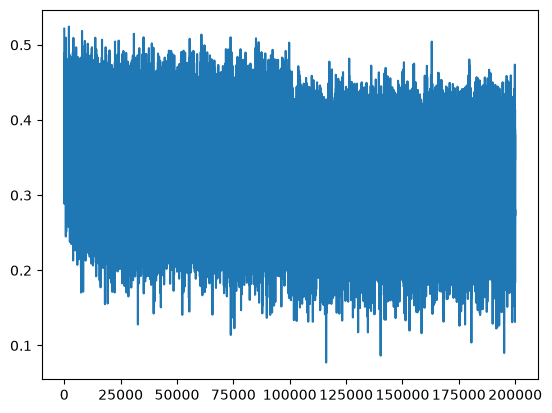

In [36]:
plt.plot(lossi)

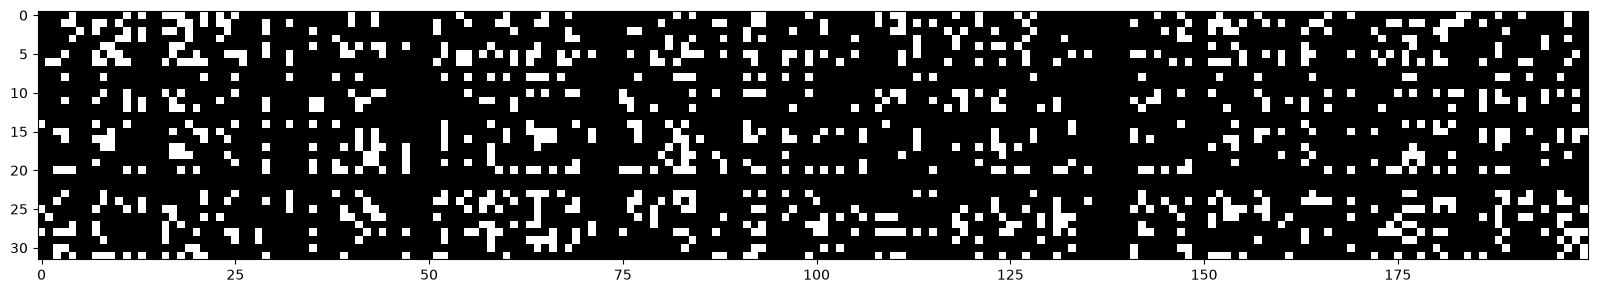

In [48]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

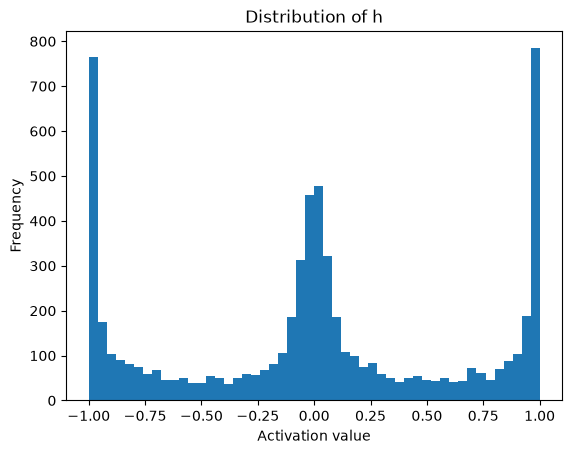

In [47]:
## Histogram of 'h'
plt.hist(h.view(-1).tolist(), bins=50)
plt.title("Distribution of h")
plt.xlabel("Activation value")
plt.ylabel("Frequency")
plt.show()

In [ ]:
print(h.mean())
print(h.std())
val = abs(h) > 0.99
print(val)

tensor(0.0316, grad_fn=<MeanBackward0>)
tensor(0.9225, grad_fn=<StdBackward0>)
tensor([[False, False, False,  ...,  True,  True,  True],
        [False,  True,  True,  ..., False,  True, False],
        [ True,  True,  True,  ..., False, False, False],
        ...,
        [ True,  True,  True,  ..., False, False, False],
        [ True, False,  True,  ..., False,  True,  True],
        [ True,  True,  True,  ..., False, False, False]])


In [49]:
(abs(h) > 0.99).float().mean()

tensor(0.1598)

In [50]:
@torch.no_grad()  # this decorator disables gradient tracking
def split_loss(split):
    x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb. view(emb. shape[0], -1) # concat into (N, block_size *n_embd)
    hpreact = embcat @ w1 + b1  # hidden layer pre-activation
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ w2 + b2 # (N, vocab_size)
    loss = F.cross_entropy (logits, y)
    print (split, loss. item())
split_loss('train')
split_loss('val')

train 2.0602071285247803
val 2.1129651069641113


## All loss after every tiny update 
# Initial Loss
Training Loss - 2.1267
Validation Loss - 2.1697

# After a quick fix to multiple 0.01 to the weight w2
Training Loss - 2.0695
Validation Loss - 2.1297

# After a quick fix via multiplying 0.1 to w1 we were to reduce the w1 and gets the less saturation for h
Training Loss - 2.0602
Validation Loss - 2.1129
